# SQL-Based Business Analytics & KPI Analysis

## Overview

This project uses SQL to analyze customer transaction data and extract key business metrics (KPIs). The goal is to demonstrate how SQL can be used to support data-driven decision-making by identifying patterns in revenue, customer behavior, and performance across different segments.


## Load Dataset

In this step, the dataset is loaded into the environment using pandas. This dataset will be used to perform SQL-based analysis and extract key business metrics.

In [1]:
import pandas as pd

# Load dataset
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


##

## SQL Setup

This step enables SQL queries within the notebook, allowing us to analyze the dataset using SQL syntax.

In [2]:
!pip install pandasql

  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=694a2242bc956da4051250145ddfd4c66068fe3081ef6608c3c9ee5882be4f58
  Stored in directory: /root/.cache/pip/wheels/15/a1/e7/6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql


##Connect SQL to Data

In [3]:
from pandasql import sqldf

# Function to run SQL queries
pysqldf = lambda q: sqldf(q, globals())

In [4]:
pysqldf("SELECT * FROM df LIMIT 5;")

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### Total Revenue

This query calculates the total revenue generated from all transactions in the dataset. This metric helps measure overall business performance.

In [5]:
query = """
SELECT SUM(total_bill) AS total_revenue
FROM df;
"""

pysqldf(query)

,total_revenue
0,4827.77


### Average Revenue

This query calculates the average transaction value, which helps understand typical customer spending behavior.

In [6]:
query = """
SELECT AVG(total_bill) AS avg_revenue
FROM df;
"""

pysqldf(query)

,avg_revenue
0,19.785943


### Revenue by Day

This query analyzes revenue distribution across different days to identify which periods generate the most business activity.

In [7]:
query = """
SELECT day, SUM(total_bill) AS revenue
FROM df
GROUP BY day
ORDER BY revenue DESC;
"""

pysqldf(query)

,day,revenue
0,Sat,1778.40
1,Sun,1627.16
2,Thur,1096.33
3,Fri,325.88


### Revenue by Group Size

This query examines how group size impacts spending behavior, helping identify which customer segments contribute most to revenue.

In [8]:
query = """
SELECT size, AVG(total_bill) AS avg_spend
FROM df
GROUP BY size
ORDER BY avg_spend DESC;
"""

pysqldf(query)

,size,avg_spend
0,6,34.830000
1,5,30.068000
2,4,28.613514
3,3,23.277632
4,2,16.448013
5,1,7.242500


### Revenue by Customer Segment (Smoker vs Non-Smoker)

This query compares revenue between different customer segments to identify potential differences in spending behavior.

In [9]:
query = """
SELECT smoker, SUM(total_bill) AS revenue
FROM df
GROUP BY smoker;
"""

pysqldf(query)

,smoker,revenue
0,No,2897.43
1,Yes,1930.34


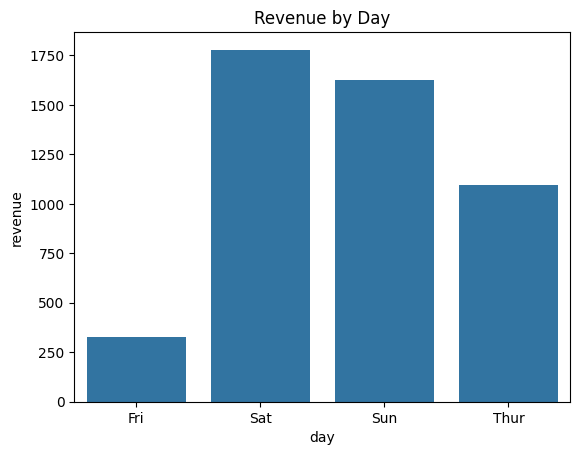

## Key Insights

* Revenue is unevenly distributed across different days, indicating that certain periods drive more business activity
* Larger group sizes tend to generate higher average spending, suggesting that group behavior plays a significant role in revenue generation
* Differences between customer segments highlight opportunities for targeted strategies
* A significant portion of revenue is concentrated in specific days, making those periods critical for maximizing business performance

## Business Impact

* High-performing days should be prioritized for staffing and operational planning
* High-spending customer segments should be targeted for retention and personalized experiences
* Understanding spending patterns allows businesses to optimize pricing, promotions, and resource allocation

## Summary

This analysis demonstrates how SQL can be used to extract meaningful business insights from transactional data. By calculating key performance metrics and analyzing customer behavior, businesses can make more informed decisions and improve overall performance. These insights provide a clear foundation for making data-driven decisions that can improve revenue performance and operational efficiency.
